# 8. Corpus-Linguistic Occurrence Analysis

This notebook asks a specific question: **which harmonic `n`-grams are informative, not merely frequent?**

The analogy is corpus linguistics. In text, raw word counts mostly surface function words like "the" and "and". Here, raw harmonic counts may mostly surface common tonal grammar. The goal is to separate those high-frequency low-information patterns from harmonic `n`-grams that are distinctive for a document group.

This notebook deliberately avoids choosing a metric on `V_n` or `H_n`. It uses only occurrence structure: document frequency, inverse document frequency, entropy across documents, TF-IDF, and one-vs-rest enrichment.

Input requirement: run notebook 7 first. This notebook consumes the broad support-thresholded `harmonic_document_terms` view, not notebook 4's top-target trend table.

## Analysis Plan

1. Re-audit candidate document definitions so the interpretation context is visible next to the statistics.
2. Load the broad support-thresholded document-term table built by notebook 7.
3. Compute document frequency, IDF, entropy across documents, TF-IDF, and one-vs-rest log enrichment.
4. Export small report tables that can drive manual inspection and the next modeling pass.

The intended reading is:

- `document_frequency_rate` high: likely harmonic stop-gram behavior.
- `tfidf_*` high: common enough in one document, but not present everywhere.
- `log2_lift` high: overrepresented relative to comparable documents.
- `normalized_entropy` low: concentrated in a few documents.

The first-pass document types are `main_genre` and `decade_1950_plus`. Artist-level analysis remains a later step because the artist distribution is too sparse for naive document statistics.

In [1]:
from pathlib import Path
import importlib
import math
import os
import sys

CWD = Path.cwd()
ROOT = CWD.parent if (CWD / "utils").exists() else CWD
MPLCONFIGDIR = ROOT / ".matplotlib-cache"
MPLCONFIGDIR.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

import duckdb
from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd

NOTEBOOK_DIR = ROOT / "notebooks"

# Force this repo's notebook utilities to win over any stale or external `utils` package.
sys.path = [p for p in sys.path if p != str(NOTEBOOK_DIR)]
sys.path.insert(0, str(NOTEBOOK_DIR))
for module_name in list(sys.modules):
    if module_name == "utils" or module_name.startswith("utils."):
        del sys.modules[module_name]

from utils import duckdb_store as ds

ds = importlib.reload(ds)
expected_duckdb_store = (NOTEBOOK_DIR / "utils" / "duckdb_store.py").resolve()
loaded_duckdb_store = Path(ds.__file__).resolve()
assert loaded_duckdb_store == expected_duckdb_store, f"Imported wrong duckdb_store module: {loaded_duckdb_store}; expected {expected_duckdb_store}"

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)

DB_PATH = ROOT / "data" / "processed" / "harmonic_trends.duckdb"
OUT_DIR = ROOT / "data" / "processed" / "corpus_linguistics"
OUT_DIR.mkdir(parents=True, exist_ok=True)

NS = tuple(range(3, 9))
MIN_DECADE = 1950
MIN_DOCUMENT_SONGS = 2_500
MIN_DOCUMENT_WINDOWS = 100_000
MIN_TERM_COUNT = 100
STOPGRAM_DF_RATE = 0.80
TOP_K = 25

assert DB_PATH.exists(), DB_PATH

{
    "python": sys.executable,
    "duckdb_version": duckdb.__version__,
    "duckdb_store": str(loaded_duckdb_store),
    "out_dir": str(OUT_DIR),
}

{'python': '/usr/local/bin/python3',
 'duckdb_version': '1.5.2',
 'duckdb_store': '/Users/juansalinas/Documents/GitHub/harmonic-trends/notebooks/utils/duckdb_store.py',
 'out_dir': '/Users/juansalinas/Documents/GitHub/harmonic-trends/data/processed/corpus_linguistics'}

## Helpers

In [2]:
def gini(values) -> float:
    vals = sorted(float(v) for v in values if pd.notna(v) and v >= 0)
    n = len(vals)
    if n == 0:
        return float("nan")
    total = sum(vals)
    if total == 0:
        return 0.0
    weighted = sum((i + 1) * v for i, v in enumerate(vals))
    return (2 * weighted) / (n * total) - (n + 1) / n


def entropy_from_counts(values) -> float:
    vals = [float(v) for v in values if pd.notna(v) and v > 0]
    total = sum(vals)
    if total <= 0:
        return 0.0
    return -sum((v / total) * math.log(v / total) for v in vals)


def normalized_entropy(values) -> float:
    vals = [float(v) for v in values if pd.notna(v) and v > 0]
    if len(vals) <= 1:
        return 0.0
    return entropy_from_counts(vals) / math.log(len(vals))


def short_harmonic_label(example: str, harmonic_id: str) -> str:
    suffix = str(harmonic_id).split("_", 1)[-1][:6]
    return f"{example} ({suffix})"

## Preflight

This notebook expects notebook 7 to have created `harmonic_document_terms` in DuckDB. If that view is missing, run notebook 7 first.

Notebook 4's `trend_harmonic` table is still useful for lightweight top-target trend inspection, but it is no longer the source for TF-IDF or document-frequency analysis.

In [3]:
con = duckdb.connect(str(DB_PATH), read_only=True)
ds.configure_connection(con)

try:
    available_tables = set(con.execute("SHOW TABLES").fetchdf()["name"])
    required = {
        "song_metadata",
        "harmonic_ngrams",
        "harmonic_document_counts",
        "harmonic_document_totals",
        "harmonic_document_songs",
        "harmonic_document_vocabulary",
        "harmonic_document_terms",
    }
    missing = sorted(required - available_tables)
    assert not missing, f"Run notebook 7 first. Missing DuckDB tables/views: {missing}"

    table_counts = con.execute(
        """
        SELECT 'song_metadata' AS table_name, COUNT(*) AS row_count FROM song_metadata
        UNION ALL SELECT 'harmonic_ngrams', COUNT(*) FROM harmonic_ngrams
        UNION ALL SELECT 'harmonic_document_counts', COUNT(*) FROM harmonic_document_counts
        UNION ALL SELECT 'harmonic_document_totals', COUNT(*) FROM harmonic_document_totals
        UNION ALL SELECT 'harmonic_document_songs', COUNT(*) FROM harmonic_document_songs
        UNION ALL SELECT 'harmonic_document_vocabulary', COUNT(*) FROM harmonic_document_vocabulary
        ORDER BY table_name
        """
    ).fetchdf()

    document_rows = con.execute(
        """
        SELECT document_type, n, COUNT(*) AS row_count
        FROM harmonic_document_terms
        GROUP BY document_type, n
        ORDER BY document_type, n
        """
    ).fetchdf()
finally:
    con.close()

table_counts, document_rows

(                     table_name  row_count
 0      harmonic_document_counts     400236
 1       harmonic_document_songs         20
 2      harmonic_document_totals        120
 3  harmonic_document_vocabulary      21180
 4               harmonic_ngrams   20696047
 5                 song_metadata     679807,
        document_type  n  row_count
 0   decade_1950_plus  3      16944
 1   decade_1950_plus  4      25797
 2   decade_1950_plus  5      31734
 3   decade_1950_plus  6      31315
 4   decade_1950_plus  7      26562
 5   decade_1950_plus  8      23198
 6         main_genre  3      25716
 7         main_genre  4      39472
 8         main_genre  5      49504
 9         main_genre  6      49625
 10        main_genre  7      42721
 11        main_genre  8      37648)

## Stratification Audit

This section compares candidate document definitions before using any of them for claims. A good first-pass stratum has enough coverage, enough groups to make document-frequency meaningful, and not so much imbalance that a few groups dominate the background.

Artist is included in the audit because it is musically tempting, but the singleton rate is expected to be severe.

In [4]:
con = duckdb.connect(str(DB_PATH), read_only=True)
ds.configure_connection(con)

try:
    total_songs = con.execute("SELECT COUNT(*) FROM song_metadata").fetchone()[0]
    candidate_group_counts = con.execute(
        """
        WITH groups AS (
            SELECT 'decade_all' AS candidate, CAST(decade AS VARCHAR) AS group_value, COUNT(*) AS song_count
            FROM song_metadata
            WHERE decade IS NOT NULL
            GROUP BY decade

            UNION ALL
            SELECT 'decade_1950_plus' AS candidate, CAST(decade AS VARCHAR) AS group_value, COUNT(*) AS song_count
            FROM song_metadata
            WHERE decade >= 1950
            GROUP BY decade

            UNION ALL
            SELECT 'main_genre' AS candidate, main_genre AS group_value, COUNT(*) AS song_count
            FROM song_metadata
            WHERE main_genre IS NOT NULL
            GROUP BY main_genre

            UNION ALL
            SELECT 'artist_id' AS candidate, artist_id AS group_value, COUNT(*) AS song_count
            FROM song_metadata
            WHERE artist_id IS NOT NULL
            GROUP BY artist_id

            UNION ALL
            SELECT 'artist_id_10_plus' AS candidate, artist_id AS group_value, COUNT(*) AS song_count
            FROM song_metadata
            WHERE artist_id IS NOT NULL
            GROUP BY artist_id
            HAVING COUNT(*) >= 10

            UNION ALL
            SELECT 'decade_main_genre_1950_plus' AS candidate,
                   CAST(decade AS VARCHAR) || ':' || main_genre AS group_value,
                   COUNT(*) AS song_count
            FROM song_metadata
            WHERE decade >= 1950 AND main_genre IS NOT NULL
            GROUP BY decade, main_genre
        )
        SELECT *
        FROM groups
        ORDER BY candidate, song_count DESC, group_value
        """
    ).fetchdf()
finally:
    con.close()

def summarize_candidate(rows: pd.DataFrame) -> pd.Series:
    counts = rows["song_count"]
    covered = int(counts.sum())
    median = float(counts.median()) if len(counts) else float("nan")
    max_count = int(counts.max()) if len(counts) else 0
    return pd.Series(
        {
            "n_groups": len(rows),
            "covered_songs": covered,
            "coverage_rate": covered / total_songs,
            "min_songs": int(counts.min()) if len(counts) else 0,
            "median_songs": median,
            "mean_songs": float(counts.mean()) if len(counts) else float("nan"),
            "max_songs": max_count,
            "max_to_median": max_count / median if median else float("inf"),
            "singleton_group_rate": float((counts == 1).mean()) if len(counts) else float("nan"),
            "gini_songs": gini(counts),
            "entropy_effective_groups": math.exp(entropy_from_counts(counts)),
        }
    )

stratification_audit = pd.DataFrame(
    [
        {"candidate": candidate, **summarize_candidate(rows).to_dict()}
        for candidate, rows in candidate_group_counts.groupby("candidate")
    ]
).sort_values(["coverage_rate", "gini_songs"], ascending=[False, True]).reset_index(drop=True)

stratification_audit

,candidate,n_groups,covered_songs,coverage_rate,min_songs,median_songs,mean_songs,max_songs,max_to_median,singleton_group_rate,gini_songs,entropy_effective_groups
0,artist_id,91556.0,510986.0,0.751663,1.0,1.0,5.581131,808.0,808.000000,0.505199,0.688414,30615.063073
1,decade_all,14.0,422181.0,0.621031,2.0,5618.0,30155.785714,185492.0,33.017444,0.000000,0.739644,4.801402
2,decade_1950_plus,8.0,421866.0,0.620567,1748.0,30942.5,52733.250000,185492.0,5.994732,0.000000,0.545798,4.773020
3,main_genre,12.0,352111.0,0.517957,2814.0,13690.5,29342.583333,85185.0,6.222198,0.000000,0.494674,7.908149
4,artist_id_10_plus,11453.0,338117.0,0.497372,10.0,19.0,29.522134,808.0,42.526316,0.000000,0.413180,8268.365869
5,decade_main_genre_1950_plus,88.0,301359.0,0.443301,1.0,1021.5,3424.534091,36262.0,35.498776,0.011364,0.691658,35.768065


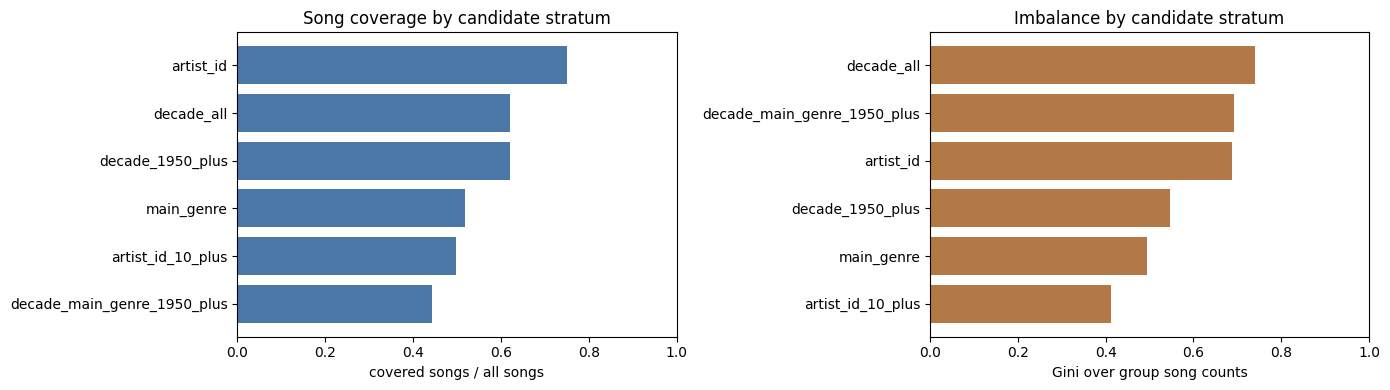

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_df = stratification_audit.sort_values("coverage_rate")
axes[0].barh(plot_df["candidate"], plot_df["coverage_rate"], color="#4c78a8")
axes[0].set_title("Song coverage by candidate stratum")
axes[0].set_xlabel("covered songs / all songs")
axes[0].set_xlim(0, 1)

plot_df = stratification_audit.sort_values("gini_songs")
axes[1].barh(plot_df["candidate"], plot_df["gini_songs"], color="#b27946")
axes[1].set_title("Imbalance by candidate stratum")
axes[1].set_xlabel("Gini over group song counts")
axes[1].set_xlim(0, 1)

fig.tight_layout()

In [6]:
# Inspect the largest and smallest cells for each candidate.
for candidate in ["decade_1950_plus", "main_genre", "artist_id_10_plus", "decade_main_genre_1950_plus"]:
    sub = candidate_group_counts[candidate_group_counts["candidate"] == candidate].copy()
    print(f"\n{candidate}: {len(sub):,} groups, {sub['song_count'].sum():,} covered songs")
    display(pd.concat([sub.head(8), sub.tail(8)]).drop_duplicates().reset_index(drop=True))


decade_1950_plus: 8 groups, 421,866 covered songs


,candidate,group_value,song_count
0,decade_1950_plus,2010,185492
1,decade_1950_plus,2000,93549
2,decade_1950_plus,2020,53594
3,decade_1950_plus,1990,42474
4,decade_1950_plus,1980,19411
5,decade_1950_plus,1970,16110
6,decade_1950_plus,1960,9488
7,decade_1950_plus,1950,1748



main_genre: 12 groups, 352,111 covered songs


,candidate,group_value,song_count
0,main_genre,pop,85185
1,main_genre,rock,67238
2,main_genre,country,53306
3,main_genre,alternative,47252
4,main_genre,pop rock,39557
5,main_genre,punk,16066
6,main_genre,metal,11315
7,main_genre,rap,11186
8,main_genre,soul,7350
9,main_genre,jazz,7001



artist_id_10_plus: 11,453 groups, 338,117 covered songs


,candidate,group_value,song_count
0,artist_id_10_plus,artist_792,808
1,artist_id_10_plus,artist_355,708
2,artist_id_10_plus,artist_304,633
3,artist_id_10_plus,artist_723,544
4,artist_id_10_plus,artist_2930,492
5,artist_id_10_plus,artist_24483,483
6,artist_id_10_plus,artist_1158,409
7,artist_id_10_plus,artist_2782,364
8,artist_id_10_plus,artist_9554,10
9,artist_id_10_plus,artist_9623,10



decade_main_genre_1950_plus: 88 groups, 301,359 covered songs


,candidate,group_value,song_count
0,decade_main_genre_1950_plus,2010:pop,36262
1,decade_main_genre_1950_plus,2010:alternative,25738
2,decade_main_genre_1950_plus,2010:rock,17195
3,decade_main_genre_1950_plus,2010:country,15997
4,decade_main_genre_1950_plus,2000:pop,13653
5,decade_main_genre_1950_plus,2000:rock,13605
6,decade_main_genre_1950_plus,2010:pop rock,11223
7,decade_main_genre_1950_plus,2020:pop,11099
8,decade_main_genre_1950_plus,1980:electronic,29
9,decade_main_genre_1950_plus,1960:reggae,26


## Stratification Decision Rule

This notebook does not pretend that one stratification is globally best.

For a first pass, a usable document type should satisfy three conditions:

1. reasonable song coverage;
2. enough groups for document frequency and one-vs-rest comparisons to mean something;
3. tolerable imbalance after filtering tiny groups.

That points to two complementary views: `main_genre` for style-specific harmonic language, and `decade_1950_plus` for historical change after the tiny early decades are removed. Artist-level analysis is deferred because most artists have too few songs for stable document statistics.

## Working Document Set

This notebook reads the document types produced by notebook 7:

- `main_genre`: noisy but musically interpretable and useful for style-specific harmonic language.
- `decade_1950_plus`: frequency-normalized historical documents after removing tiny early decades.

We keep document types separate. Mixing decade documents and genre documents in one TF-IDF universe would make document frequency harder to interpret.

In [7]:
con = duckdb.connect(str(DB_PATH), read_only=True)
ds.configure_connection(con)

try:
    harmonic_terms = con.execute(
        """
        SELECT
            document_type,
            document_value,
            document_id,
            n,
            harmonic_id,
            example_ngram,
            global_count,
            global_frequency,
            count,
            total_windows,
            frequency AS tf,
            song_count
        FROM harmonic_document_terms
        WHERE song_count >= ?
          AND total_windows >= ?
        ORDER BY document_type, document_value, n, count DESC, harmonic_id
        """,
        [MIN_DOCUMENT_SONGS, MIN_DOCUMENT_WINDOWS],
    ).fetchdf()
finally:
    con.close()

assert not harmonic_terms.empty, "No document terms after support filters. Lower MIN_DOCUMENT_SONGS or MIN_DOCUMENT_WINDOWS."

harmonic_terms.head(), harmonic_terms.shape

(      document_type document_value            document_id  n          harmonic_id example_ngram  global_count  global_frequency  count  total_windows        tf  song_count
 0  decade_1950_plus           1960  decade_1950_plus:1960  3  H3_ede3c4f53675bbb0         G C G       2203877          0.043525  41181         586092  0.070264        9488
 1  decade_1950_plus           1960  decade_1950_plus:1960  3  H3_35d6bfda85b78e3b         C G C       1907266          0.037667  36607         586092  0.062459        9488
 2  decade_1950_plus           1960  decade_1950_plus:1960  3  H3_614d8a0823c338e1         D G C       1183031          0.023364  19478         586092  0.033234        9488
 3  decade_1950_plus           1960  decade_1950_plus:1960  3  H3_5f9ccd30c6b35272         C D G       1273259          0.025146  16960         586092  0.028937        9488
 4  decade_1950_plus           1960  decade_1950_plus:1960  3  H3_4e99eecf61b0edec         C G D       1827464          0.036091  15519

In [8]:
document_summary = (
    harmonic_terms[["document_type", "document_id", "document_value", "song_count", "n", "total_windows"]]
    .drop_duplicates()
    .groupby(["document_type", "n"], as_index=False)
    .agg(
        n_documents=("document_id", "nunique"),
        total_songs=("song_count", "sum"),
        min_songs=("song_count", "min"),
        median_songs=("song_count", "median"),
        max_songs=("song_count", "max"),
        total_windows=("total_windows", "sum"),
        min_windows=("total_windows", "min"),
        median_windows=("total_windows", "median"),
        max_windows=("total_windows", "max"),
    )
)

document_summary

,document_type,n,n_documents,total_songs,min_songs,median_songs,max_songs,total_windows,min_windows,median_windows,max_windows
0,decade_1950_plus,3,7,420118,9488,42474.0,185492,31129039,586092,3026960.0,14216707
1,decade_1950_plus,4,7,420118,9488,42474.0,185492,30709061,576612,2984506.0,14031272
2,decade_1950_plus,5,7,420118,9488,42474.0,185492,30289173,567138,2942066.0,13845874
3,decade_1950_plus,6,7,420118,9488,42474.0,185492,29869443,557667,2899635.0,13660551
4,decade_1950_plus,7,7,420118,9488,42474.0,185492,29450137,548216,2857283.0,13475344
5,decade_1950_plus,8,7,420118,9488,42474.0,185492,29031325,538773,2815019.0,13290284
6,main_genre,3,12,352111,2814,13690.5,85185,26629631,216106,1120002.0,6596797
7,main_genre,4,12,352111,2814,13690.5,85185,26277654,213292,1106313.5,6511630
8,main_genre,5,12,352111,2814,13690.5,85185,25925760,210478,1092629.0,6426474
9,main_genre,6,12,352111,2814,13690.5,85185,25574015,207666,1078949.5,6341358


## Corpus Statistics for Harmonic Classes

This is the direct analogue of a term-statistics table in text analysis. The most useful fields are:

- `document_frequency_rate`: how stopword-like the harmonic class is across documents.
- `idf`: inverse document frequency with light smoothing.
- `normalized_entropy`: whether the term mass is spread evenly across documents or concentrated.
- `background_frequency`: count divided by all windows in that document type and `n`.

Unlike the earlier top-target trend table, this uses a broader support-thresholded harmonic vocabulary built in notebook 7, so document frequency and TF-IDF should now carry information.

In [9]:
doc_counts = (
    harmonic_terms[["document_type", "n", "document_id", "total_windows"]]
    .drop_duplicates()
    .groupby(["document_type", "n"], as_index=False)
    .agg(n_documents=("document_id", "nunique"), corpus_windows=("total_windows", "sum"))
)

term_stats = (
    harmonic_terms
    .groupby(["document_type", "n", "harmonic_id"], as_index=False)
    .agg(
        representative_example_ngram=("example_ngram", "first"),
        total_count=("count", "sum"),
        document_frequency=("document_id", "nunique"),
        max_document_count=("count", "max"),
        max_document_tf=("tf", "max"),
        mean_document_tf_observed=("tf", "mean"),
        normalized_entropy=("count", normalized_entropy),
    )
    .merge(doc_counts, on=["document_type", "n"], how="left")
)

term_stats["document_frequency_rate"] = term_stats["document_frequency"] / term_stats["n_documents"]
term_stats["idf"] = (1 + term_stats["n_documents"]).div(1 + term_stats["document_frequency"]).map(math.log) + 1
term_stats["background_frequency"] = term_stats["total_count"] / term_stats["corpus_windows"]
term_stats = term_stats.sort_values(["document_type", "n", "total_count"], ascending=[True, True, False]).reset_index(drop=True)

term_stats.head(20)

,document_type,n,harmonic_id,representative_example_ngram,total_count,document_frequency,max_document_count,max_document_tf,mean_document_tf_observed,normalized_entropy,n_documents,corpus_windows,document_frequency_rate,idf,background_frequency
0,decade_1950_plus,3,H3_ede3c4f53675bbb0,G C G,1349197,7,550307,0.070264,0.050943,0.836172,7,31129039,1.0,1.0,0.043342
1,decade_1950_plus,3,H3_35d6bfda85b78e3b,C G C,1182391,7,485709,0.062459,0.044686,0.835333,7,31129039,1.0,1.0,0.037984
2,decade_1950_plus,3,H3_4e99eecf61b0edec,C G D,1129297,7,539155,0.038340,0.032995,0.753586,7,31129039,1.0,1.0,0.036278
3,decade_1950_plus,3,H3_5f9ccd30c6b35272,C D G,754983,7,308486,0.030663,0.026467,0.821173,7,31129039,1.0,1.0,0.024253
4,decade_1950_plus,3,H3_614d8a0823c338e1,D G C,719108,7,300106,0.033234,0.026132,0.826291,7,31129039,1.0,1.0,0.023101
5,decade_1950_plus,3,H3_aef0281c29774fb7,C G Amin,691214,7,369382,0.025982,0.016567,0.677027,7,31129039,1.0,1.0,0.022205
6,decade_1950_plus,3,H3_0859351c7b2e5686,D C G,651984,7,300853,0.021958,0.020370,0.778006,7,31129039,1.0,1.0,0.020945
7,decade_1950_plus,3,H3_cb0f464e362cf3bc,Emin C G,599048,7,352591,0.024801,0.012500,0.606674,7,31129039,1.0,1.0,0.019244
8,decade_1950_plus,3,H3_2bd39a67fe3535a8,G D C,577788,7,257476,0.019971,0.018411,0.788430,7,31129039,1.0,1.0,0.018561
9,decade_1950_plus,3,H3_950fb5de7bd72a8d,G Amin F,539550,7,296658,0.020867,0.012189,0.653532,7,31129039,1.0,1.0,0.017333


In [10]:
stopgram_candidates = (
    term_stats[
        (term_stats["document_frequency_rate"] >= STOPGRAM_DF_RATE)
        & (term_stats["total_count"] >= MIN_TERM_COUNT)
    ]
    .sort_values(["document_type", "n", "document_frequency_rate", "total_count"], ascending=[True, True, False, False])
    .reset_index(drop=True)
)

stopgram_candidates[[
    "document_type",
    "n",
    "harmonic_id",
    "representative_example_ngram",
    "total_count",
    "document_frequency",
    "n_documents",
    "document_frequency_rate",
    "background_frequency",
    "normalized_entropy",
]].head(40)

,document_type,n,harmonic_id,representative_example_ngram,total_count,document_frequency,n_documents,document_frequency_rate,background_frequency,normalized_entropy
0,decade_1950_plus,3,H3_ede3c4f53675bbb0,G C G,1349197,7,7,1.0,0.043342,0.836172
1,decade_1950_plus,3,H3_35d6bfda85b78e3b,C G C,1182391,7,7,1.0,0.037984,0.835333
2,decade_1950_plus,3,H3_4e99eecf61b0edec,C G D,1129297,7,7,1.0,0.036278,0.753586
3,decade_1950_plus,3,H3_5f9ccd30c6b35272,C D G,754983,7,7,1.0,0.024253,0.821173
4,decade_1950_plus,3,H3_614d8a0823c338e1,D G C,719108,7,7,1.0,0.023101,0.826291
5,decade_1950_plus,3,H3_aef0281c29774fb7,C G Amin,691214,7,7,1.0,0.022205,0.677027
6,decade_1950_plus,3,H3_0859351c7b2e5686,D C G,651984,7,7,1.0,0.020945,0.778006
7,decade_1950_plus,3,H3_cb0f464e362cf3bc,Emin C G,599048,7,7,1.0,0.019244,0.606674
8,decade_1950_plus,3,H3_2bd39a67fe3535a8,G D C,577788,7,7,1.0,0.018561,0.788430
9,decade_1950_plus,3,H3_950fb5de7bd72a8d,G Amin F,539550,7,7,1.0,0.017333,0.653532


## TF-IDF

TF-IDF asks: which harmonic classes are prominent in a document but not ubiquitous across documents of the same type?

Two variants are exported:

- `tfidf_frequency = frequency * idf`, which respects each stratum's denominator.
- `tfidf_log_count = log1p(count) * idf`, which favors supported terms while still downweighting ubiquitous classes.

In [11]:
tfidf = harmonic_terms.merge(
    term_stats[["document_type", "n", "harmonic_id", "document_frequency", "document_frequency_rate", "idf", "background_frequency"]],
    on=["document_type", "n", "harmonic_id"],
    how="left",
)
tfidf["tfidf_frequency"] = tfidf["tf"] * tfidf["idf"]
tfidf["tfidf_log_count"] = tfidf["count"].map(lambda x: math.log1p(x)) * tfidf["idf"]
tfidf = tfidf.sort_values(["document_type", "n", "document_id", "tfidf_log_count"], ascending=[True, True, True, False]).reset_index(drop=True)

tfidf_top = (
    tfidf[tfidf["count"] >= MIN_TERM_COUNT]
    .sort_values(["document_type", "n", "document_id", "tfidf_log_count"], ascending=[True, True, True, False])
    .groupby(["document_type", "n", "document_id"], as_index=False)
    .head(TOP_K)
)

tfidf_top[[
    "document_type", "document_value", "n", "harmonic_id", "example_ngram", "count", "tf", "idf", "tfidf_log_count", "document_frequency_rate"
]].head(40)

,document_type,document_value,n,harmonic_id,example_ngram,count,tf,idf,tfidf_log_count,document_frequency_rate
0,decade_1950_plus,1960,3,H3_ede3c4f53675bbb0,G C G,41181,0.070264,1.0,10.625757,1.0
1,decade_1950_plus,1960,3,H3_35d6bfda85b78e3b,C G C,36607,0.062459,1.0,10.508022,1.0
2,decade_1950_plus,1960,3,H3_614d8a0823c338e1,D G C,19478,0.033234,1.0,9.877092,1.0
3,decade_1950_plus,1960,3,H3_5f9ccd30c6b35272,C D G,16960,0.028937,1.0,9.738672,1.0
4,decade_1950_plus,1960,3,H3_4e99eecf61b0edec,C G D,15519,0.026479,1.0,9.649885,1.0
5,decade_1950_plus,1960,3,H3_71538b04eaf320f0,G C D,11394,0.019441,1.0,9.340930,1.0
6,decade_1950_plus,1960,3,H3_0859351c7b2e5686,D C G,10399,0.017743,1.0,9.249561,1.0
7,decade_1950_plus,1960,3,H3_ae75bf5fb2d800d6,G F G,9489,0.016190,1.0,9.157994,1.0
8,decade_1950_plus,1960,3,H3_2bd39a67fe3535a8,G D C,9317,0.015897,1.0,9.139703,1.0
9,decade_1950_plus,1960,3,H3_3569c7a41696606d,C G7 C,8304,0.014168,1.0,9.024613,1.0


## One-vs-Rest Enrichment

This is the keyness-style score from corpus linguistics: a harmonic class is interesting for a document if it is more frequent there than in the rest of the same document type.

The score below uses additive smoothing so zero rest counts do not create infinite lift. Positive `log2_lift` means overrepresentation in the document; negative values mean underrepresentation.

In [12]:
vocab_size = (
    harmonic_terms
    .groupby(["document_type", "n"], as_index=False)
    .agg(vocab_size=("harmonic_id", "nunique"))
)

enrichment = tfidf.merge(
    doc_counts,
    on=["document_type", "n"],
    how="left",
    suffixes=("", "_corpus"),
).merge(
    term_stats[["document_type", "n", "harmonic_id", "total_count"]],
    on=["document_type", "n", "harmonic_id"],
    how="left",
).merge(
    vocab_size,
    on=["document_type", "n"],
    how="left",
)

alpha = 0.5
enrichment["rest_count"] = enrichment["total_count"] - enrichment["count"]
enrichment["rest_windows"] = enrichment["corpus_windows"] - enrichment["total_windows"]
enrichment["smoothed_doc_frequency"] = (enrichment["count"] + alpha) / (enrichment["total_windows"] + alpha * enrichment["vocab_size"])
enrichment["smoothed_rest_frequency"] = (enrichment["rest_count"] + alpha) / (enrichment["rest_windows"] + alpha * enrichment["vocab_size"])
enrichment["log2_lift"] = (enrichment["smoothed_doc_frequency"] / enrichment["smoothed_rest_frequency"]).map(lambda x: math.log2(x) if x > 0 else float("nan"))
enrichment["lift"] = 2 ** enrichment["log2_lift"]

enrichment_top = (
    enrichment[(enrichment["count"] >= MIN_TERM_COUNT) & (enrichment["rest_windows"] > 0)]
    .sort_values(["document_type", "n", "document_id", "log2_lift", "count"], ascending=[True, True, True, False, False])
    .groupby(["document_type", "n", "document_id"], as_index=False)
    .head(TOP_K)
)

enrichment_top[[
    "document_type", "document_value", "n", "harmonic_id", "example_ngram", "count", "tf", "smoothed_rest_frequency", "lift", "log2_lift"
]].head(40)

,document_type,document_value,n,harmonic_id,example_ngram,count,tf,smoothed_rest_frequency,lift,log2_lift
84,decade_1950_plus,1960,3,H3_26faeefee79c95c8,A7 E7 B7,973,0.001660,0.000102,16.279387,4.024974
150,decade_1950_plus,1960,3,H3_c71c0406d475a06d,E7 B7 A7,558,0.000952,0.000065,14.720357,3.879741
146,decade_1950_plus,1960,3,H3_cdc67232bfce2ee6,B7 A7 E7,572,0.000976,0.000068,14.403309,3.848328
44,decade_1950_plus,1960,3,H3_255cd3a6183b1e28,E7 A7 E7,1870,0.003191,0.000302,10.558889,3.400386
48,decade_1950_plus,1960,3,H3_d72efad7015b95ad,A7 E7 A7,1781,0.003039,0.000290,10.471271,3.388365
68,decade_1950_plus,1960,3,H3_fd133c5caf91b969,E7 A7 D7,1321,0.002254,0.000253,8.904516,3.154537
436,decade_1950_plus,1960,3,H3_1b6566186f03f0be,A7 E7 A,133,0.000227,0.000027,8.504668,3.088255
467,decade_1950_plus,1960,3,H3_bb9253d740e428ef,E E7 B7,121,0.000206,0.000025,8.234367,3.041658
407,decade_1950_plus,1960,3,H3_b3eec5b70dc0bdec,A7 D7 A,150,0.000256,0.000032,8.033170,3.005969
344,decade_1950_plus,1960,3,H3_d2d0e826d69bac2f,D A7 D7,192,0.000328,0.000041,7.962603,2.993240


## Quick Reading Views

These compact views are intended for inspection, not final claims. They help separate three cases:

- high count and high document frequency: likely harmonic stop-grams;
- high TF-IDF: supported but not ubiquitous;
- high lift: characteristic of one group relative to comparable groups.

In [13]:
for document_type in sorted(harmonic_terms["document_type"].unique()):
    print(f"\n=== {document_type}: stop-gram candidates ===")
    display(
        stopgram_candidates[stopgram_candidates["document_type"] == document_type]
        .groupby("n", as_index=False)
        .head(5)[["n", "representative_example_ngram", "harmonic_id", "total_count", "document_frequency_rate", "background_frequency"]]
    )

    print(f"\n=== {document_type}: top TF-IDF examples ===")
    display(
        tfidf_top[tfidf_top["document_type"] == document_type]
        .groupby(["n", "document_value"], as_index=False)
        .head(3)[["document_value", "n", "example_ngram", "harmonic_id", "count", "tfidf_log_count", "document_frequency_rate"]]
        .head(36)
    )

    print(f"\n=== {document_type}: top enrichment examples ===")
    display(
        enrichment_top[enrichment_top["document_type"] == document_type]
        .groupby(["n", "document_value"], as_index=False)
        .head(3)[["document_value", "n", "example_ngram", "harmonic_id", "count", "lift", "log2_lift"]]
        .head(36)
    )


=== decade_1950_plus: stop-gram candidates ===


,n,representative_example_ngram,harmonic_id,total_count,document_frequency_rate,background_frequency
0,3,G C G,H3_ede3c4f53675bbb0,1349197,1.0,0.043342
1,3,C G C,H3_35d6bfda85b78e3b,1182391,1.0,0.037984
2,3,C G D,H3_4e99eecf61b0edec,1129297,1.0,0.036278
3,3,C D G,H3_5f9ccd30c6b35272,754983,1.0,0.024253
4,3,D G C,H3_614d8a0823c338e1,719108,1.0,0.023101
2227,4,C G C G,H4_ea9c499da62b44ab,635587,1.0,0.020697
2228,4,G C G C,H4_f6775591139fd92b,617889,1.0,0.020121
2229,4,G D C G,H4_f7d99426b468a649,335832,1.0,0.010936
2230,4,C G Amin F,H4_6acd8312eceec65f,333561,1.0,0.010862
2231,4,F C G Amin,H4_d8382171eefdad97,326520,1.0,0.010633



=== decade_1950_plus: top TF-IDF examples ===


,document_value,n,example_ngram,harmonic_id,count,tfidf_log_count,document_frequency_rate
0,1960,3,G C G,H3_ede3c4f53675bbb0,41181,10.625757,1.0
1,1960,3,C G C,H3_35d6bfda85b78e3b,36607,10.508022,1.0
2,1960,3,D G C,H3_614d8a0823c338e1,19478,9.877092,1.0
2123,1970,3,G C G,H3_ede3c4f53675bbb0,73072,11.199214,1.0
2124,1970,3,C G C,H3_35d6bfda85b78e3b,64174,11.069369,1.0
2125,1970,3,C G D,H3_4e99eecf61b0edec,36127,10.494823,1.0
4345,1980,3,G C G,H3_ede3c4f53675bbb0,79908,11.288644,1.0
4346,1980,3,C G C,H3_35d6bfda85b78e3b,69716,11.152199,1.0
4347,1980,3,C D G,H3_5f9ccd30c6b35272,45067,10.715928,1.0
6584,1990,3,G C G,H3_ede3c4f53675bbb0,159883,11.982204,1.0



=== decade_1950_plus: top enrichment examples ===


...

,n,representative_example_ngram,harmonic_id,total_count,document_frequency_rate,background_frequency
20774,3,G C G,H3_ede3c4f53675bbb0,1154175,1.0,0.043342
20775,3,C G C,H3_35d6bfda85b78e3b,1011094,1.0,0.037969
20776,3,C G D,H3_4e99eecf61b0edec,953728,1.0,0.035815
20777,3,C D G,H3_5f9ccd30c6b35272,637270,1.0,0.023931
20778,3,D G C,H3_614d8a0823c338e1,609201,1.0,0.022877
22919,4,C G C G,H4_ea9c499da62b44ab,547468,1.0,0.020834
22920,4,G C G C,H4_f6775591139fd92b,529696,1.0,0.020158
22921,4,G D C G,H4_f7d99426b468a649,288698,1.0,0.010986
22922,4,C G D C,H4_6f7528dbba7be76e,279418,1.0,0.010633
22923,4,D C G D,H4_8af854a3cac45246,277082,1.0,0.010544



=== main_genre: top TF-IDF examples ===


,document_value,n,example_ngram,harmonic_id,count,tfidf_log_count,document_frequency_rate
145398,alternative,3,G C G,H3_ede3c4f53675bbb0,137104,11.828502,1.0
145399,alternative,3,C G C,H3_35d6bfda85b78e3b,126367,11.746954,1.0
145400,alternative,3,C G D,H3_4e99eecf61b0edec,111663,11.623250,1.0
147637,country,3,G C G,H3_ede3c4f53675bbb0,291970,12.584410,1.0
147638,country,3,C G C,H3_35d6bfda85b78e3b,256253,12.453924,1.0
147639,country,3,C G D,H3_4e99eecf61b0edec,186805,12.137826,1.0
149873,electronic,3,C G D,H3_4e99eecf61b0edec,9588,9.168372,1.0
149874,electronic,3,Emin C G,H3_cb0f464e362cf3bc,8145,9.005282,1.0
149875,electronic,3,C G Amin,H3_aef0281c29774fb7,7463,8.917847,1.0
151727,jazz,3,G C G,H3_ede3c4f53675bbb0,21863,9.992597,1.0



=== main_genre: top enrichment examples ===


,document_value,n,example_ngram,harmonic_id,count,lift,log2_lift
146138,alternative,3,Amaj7 D Dmin,H3_e88c5bfff46181b5,233,3.962244,1.986318
145999,alternative,3,Dmin Fmaj7 C,H3_69ead3a903aab0d6,465,3.311148,1.727332
146342,alternative,3,G F Cmaj7,H3_7c3f0163e456b122,274,3.017571,1.593388
147669,country,3,F C G7,H3_399df86a5aae7301,20483,6.458954,2.691300
147773,country,3,C D7 G7,H3_2bf4029c49a92116,2734,5.217659,2.383403
147660,country,3,D7 G C,H3_c7a280c94f7b2c52,32125,5.208029,2.380738
150005,electronic,3,Dmaj7 Dadd13 Dmaj7,H3_3ed58771d47d3721,160,6.416840,2.681863
150043,electronic,3,Emin G Amin7,H3_0c38f164198732ce,108,5.957829,2.574787
150026,electronic,3,Amin7 D Emin,H3_887caf3a8e7c4964,126,5.055847,2.337953
151970,jazz,3,F7 E7 A7,H3_1d9a8e98522c8549,182,22.756605,4.508213


## Export Report Tables

These CSVs are convenient report/inspection outputs. The source document-term counts remain in DuckDB as `harmonic_document_terms`.

In [14]:
paths = {
    "stratification_audit": OUT_DIR / "stratification_audit.csv",
    "candidate_group_counts": OUT_DIR / "candidate_group_counts.csv",
    "document_summary": OUT_DIR / "document_summary.csv",
    "harmonic_document_terms": OUT_DIR / "harmonic_document_terms.csv",
    "harmonic_term_stats": OUT_DIR / "harmonic_term_stats.csv",
    "harmonic_stopgram_candidates": OUT_DIR / "harmonic_stopgram_candidates.csv",
    "harmonic_tfidf": OUT_DIR / "harmonic_tfidf.csv",
    "harmonic_tfidf_top": OUT_DIR / "harmonic_tfidf_top.csv",
    "harmonic_enrichment": OUT_DIR / "harmonic_enrichment.csv",
    "harmonic_enrichment_top": OUT_DIR / "harmonic_enrichment_top.csv",
}

stratification_audit.to_csv(paths["stratification_audit"], index=False)
candidate_group_counts.to_csv(paths["candidate_group_counts"], index=False)
document_summary.to_csv(paths["document_summary"], index=False)
harmonic_terms.to_csv(paths["harmonic_document_terms"], index=False)
term_stats.to_csv(paths["harmonic_term_stats"], index=False)
stopgram_candidates.to_csv(paths["harmonic_stopgram_candidates"], index=False)
tfidf.to_csv(paths["harmonic_tfidf"], index=False)
tfidf_top.to_csv(paths["harmonic_tfidf_top"], index=False)
enrichment.to_csv(paths["harmonic_enrichment"], index=False)
enrichment_top.to_csv(paths["harmonic_enrichment_top"], index=False)

paths

{'stratification_audit': PosixPath('/Users/juansalinas/Documents/GitHub/harmonic-trends/data/processed/corpus_linguistics/stratification_audit.csv'),
 'candidate_group_counts': PosixPath('/Users/juansalinas/Documents/GitHub/harmonic-trends/data/processed/corpus_linguistics/candidate_group_counts.csv'),
 'document_summary': PosixPath('/Users/juansalinas/Documents/GitHub/harmonic-trends/data/processed/corpus_linguistics/document_summary.csv'),
 'harmonic_document_terms': PosixPath('/Users/juansalinas/Documents/GitHub/harmonic-trends/data/processed/corpus_linguistics/harmonic_document_terms.csv'),
 'harmonic_term_stats': PosixPath('/Users/juansalinas/Documents/GitHub/harmonic-trends/data/processed/corpus_linguistics/harmonic_term_stats.csv'),
 'harmonic_stopgram_candidates': PosixPath('/Users/juansalinas/Documents/GitHub/harmonic-trends/data/processed/corpus_linguistics/harmonic_stopgram_candidates.csv'),
 'harmonic_tfidf': PosixPath('/Users/juansalinas/Documents/GitHub/harmonic-trends/da

## Recommended Next Move

Use this notebook's outputs to compare `main_genre` and `decade_1950_plus` side by side. If the same harmonic families are stop-gram-like in both, mark them as low-information global grammar. If a family has high lift or TF-IDF in one stratum but not the other, it is a candidate for musical interpretation.

If `idf` still collapses toward 1 for most rows, lower `MIN_GLOBAL_HARMONIC_COUNT` in notebook 7 and rebuild `harmonic_document_terms`.

For artist-level analysis, avoid treating 91k artists as equal documents. Use one of these designs instead:

1. top artists by song count, with a minimum support threshold;
2. artist-within-genre comparisons, so artists are compared against a relevant background;
3. hierarchical pooling, where artist estimates shrink toward genre or decade backgrounds;
4. song-level document terms, if we later decide to store a sparse song-by-`H_n` matrix.